NULL

Warning message:
"Removed 4 rows containing non-finite values (stat_boxplot)."
Warning message:
"Removed 4 rows containing missing values (geom_point)."
Warning message:
"Removed 4 rows containing non-finite values (stat_boxplot)."
Warning message:
"Removed 4 rows containing missing values (geom_point)."


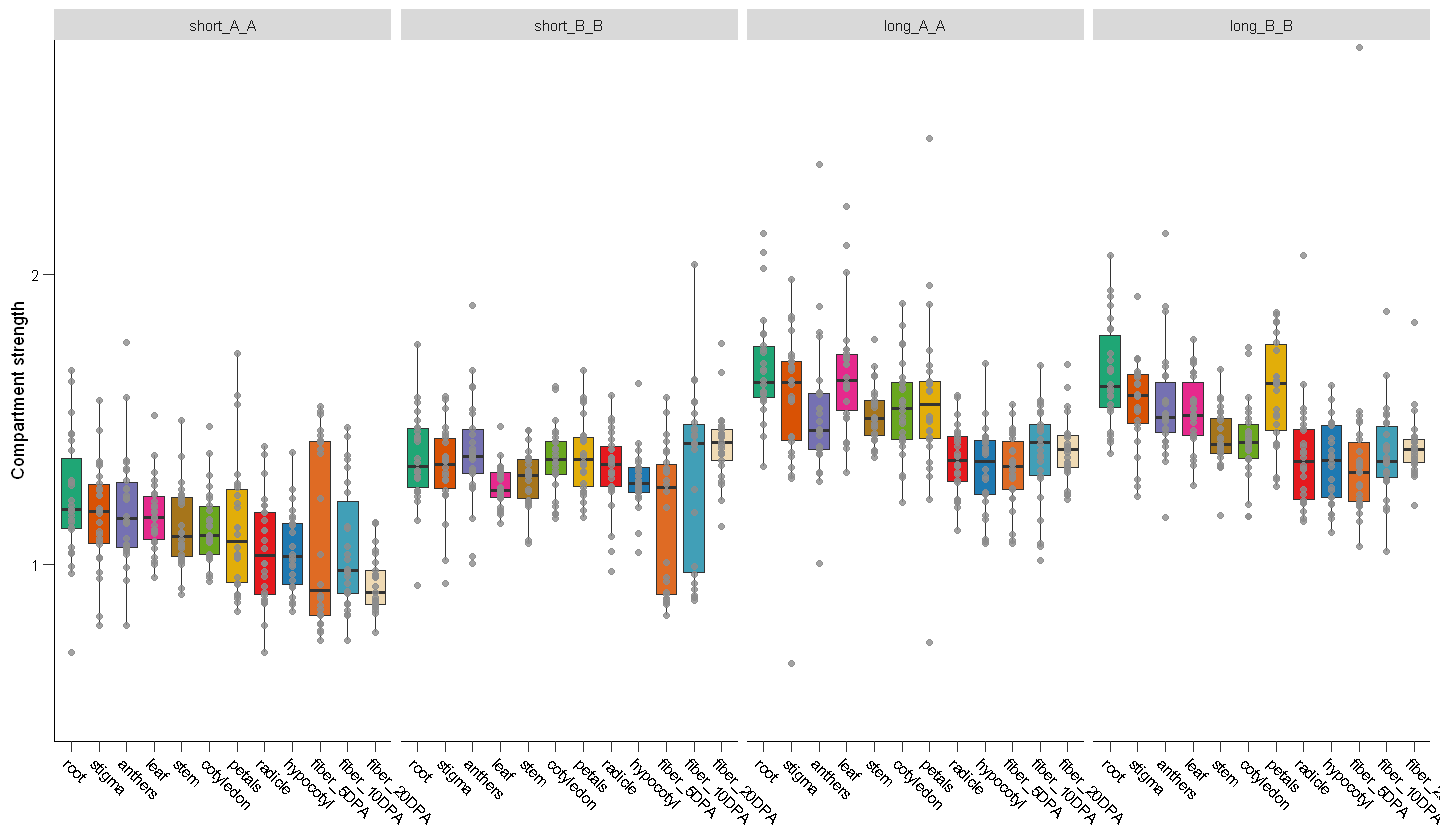

In [12]:
## 分析不同类型的loop对于基因表达的影响
options(repr.plot.width=12)
library(ggplot2)
library(reshape2)
rm(list = ls())
setwd("G:/J668_multip_tissue_3D-genome/HiC/compartment/pentad/cis")
library(ggplot2)
library(ggpubr)
df <- read.csv("cis_strength.txt", sep = "\t", header =T)
df_long <-  melt(df, id.vars=c("tags", 'chrom'))
df_long <- within(df_long, tags <- factor(tags, levels = c("root", "stigma", "anthers", "leaf", "stem", "cotyledon", "petals", "radicle", "hypocotyl", "fiber_5DPA", "fiber_10DPA", "fiber_20DPA")))
with(df, levels(tags))
#endregiondf_long
#compaired <- list(c("G-G", "G-N"), c("G-N", "Not loop"), c("G-G", "Not loop"))
fg <- ggplot(df_long, aes(x = tags, y = value, fill = tags)) +
geom_boxplot(outlier.colour = NA, notch = FALSE) +
geom_point(colour = '#8C8C8C', alpha = 0.8)+
#geom_violin()+
facet_grid(.~variable) +
coord_cartesian(ylim = c(0.5,2.7))+
labs(y = "Compartment strength", x = NULL) +
theme(panel.background = element_blank(),
     panel.grid = element_blank(),
     axis.line = element_line(linetype = 1),
     legend.position = "none",
     axis.ticks.length = unit(0.25, "cm"),
     axis.text = element_text(color = "black"),
     axis.text.x = element_text(angle = 315, hjust=0)
     ) +
     scale_fill_manual(values = c("#1FA675", "#D95204", "#7571B2", "#E6298D", "#A6751B", "#69A71E", "#E2AE09", "#E6191E", "#1E79B2", "#df6b24", "#419FB7", "#efdab4"))
     #geom_signif(comparisons = compaired, step_increase = 0.02,test =wilcox.test, tip_length=0.01, textsize = 2, y_position=11, annotations=c("***", "***", "***"))
fg
ggsave(plot =fg, filename = 'cis_strength.pdf', height =5.5, width = 12)

NULL

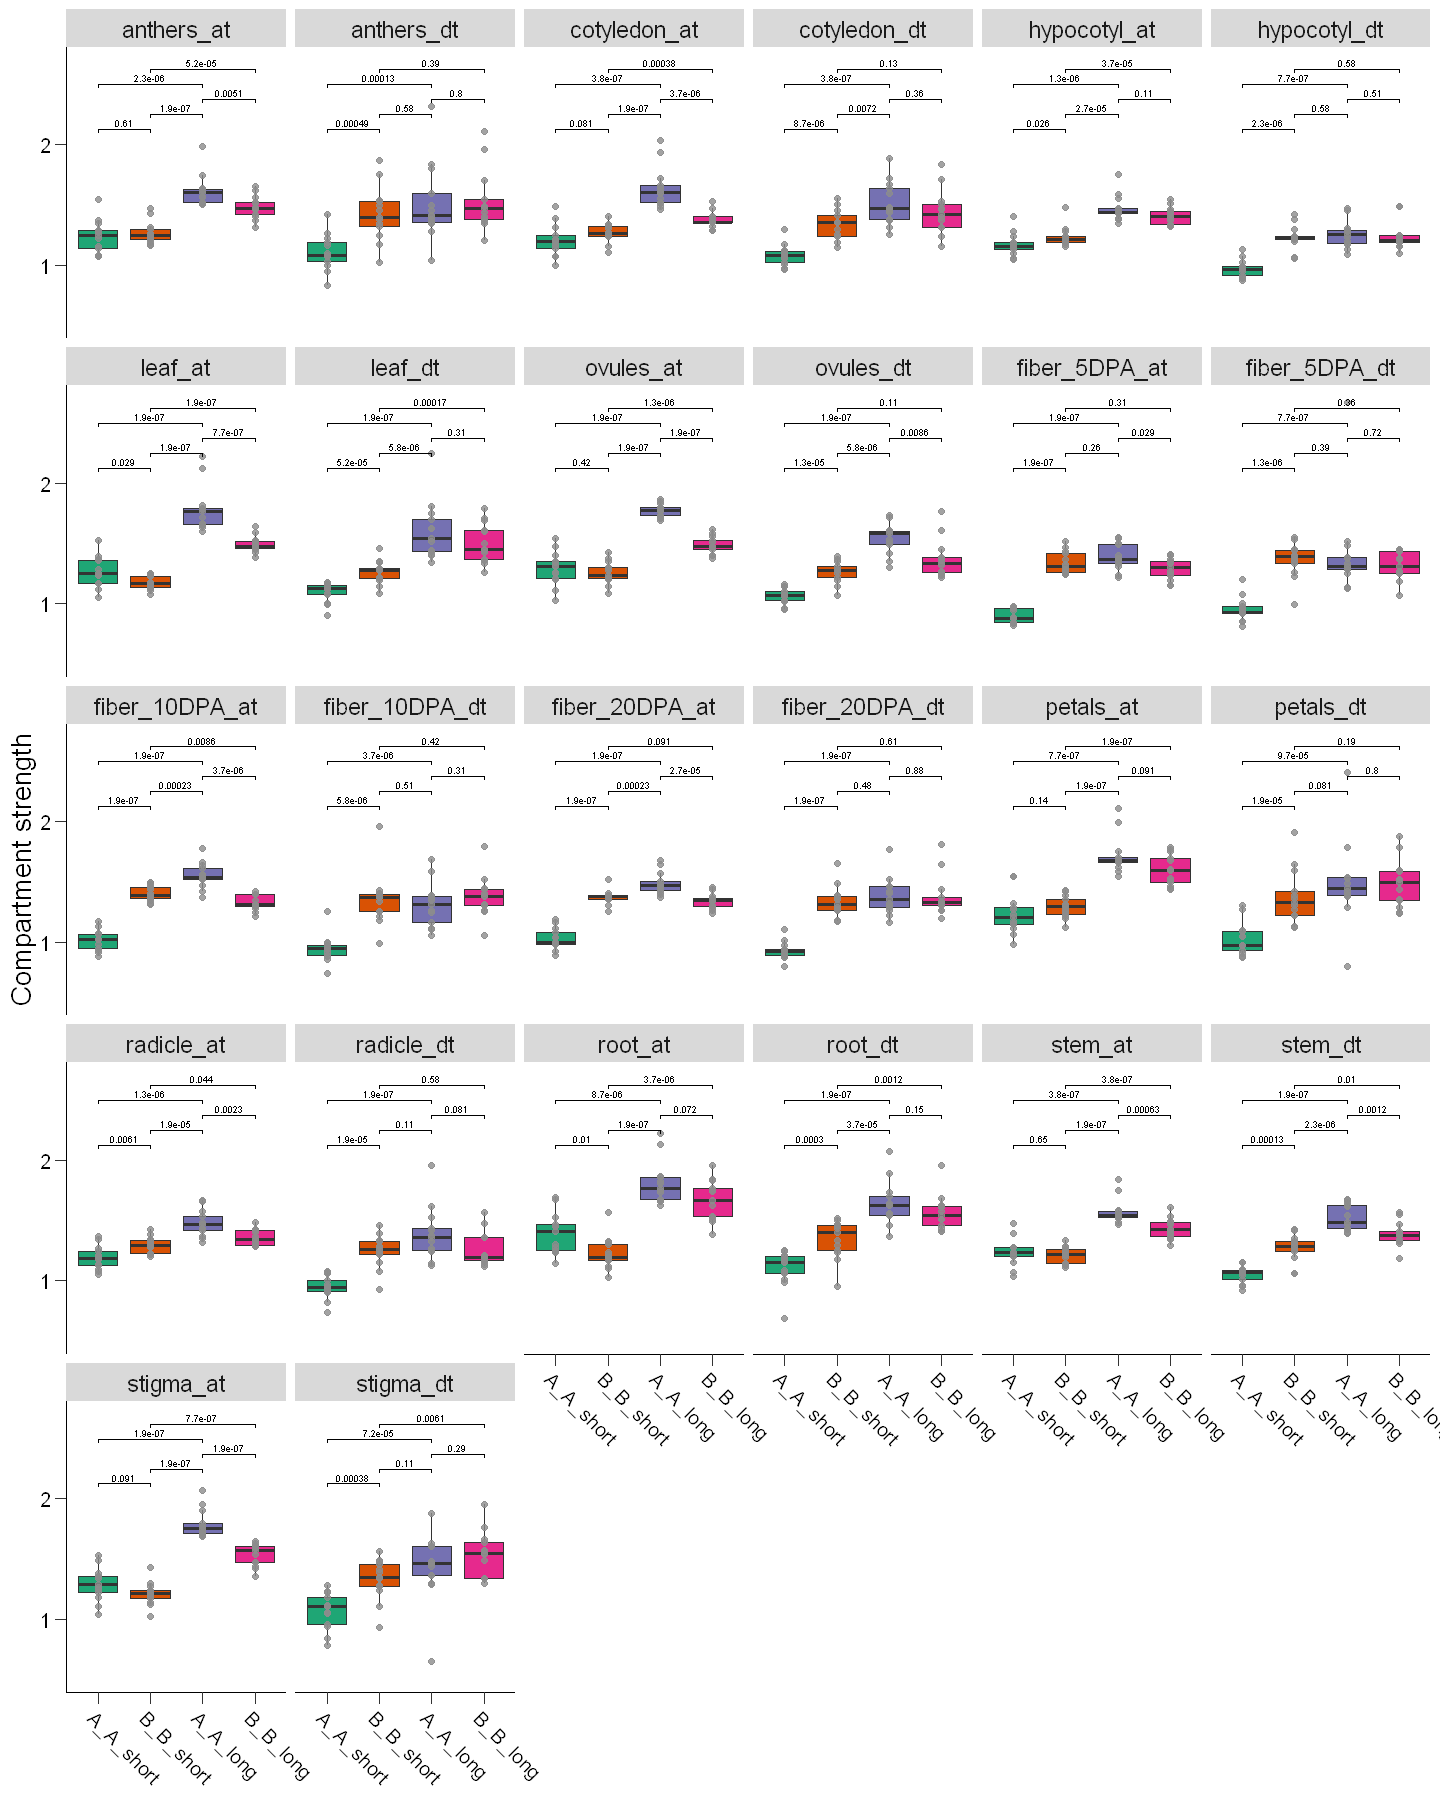

In [30]:
## 分析不同类型的loop对于基因表达的影响
options(repr.plot.width=12, repr.plot.height=15)
library(ggplot2)
library(reshape2)
rm(list = ls())
setwd("G:/J668_multip_tissue_3D-genome/HiC/compartment/pentad/cis")
library(ggplot2)
library(ggpubr)
df <- read.csv("all_sample_cis_strength_subg.txt", sep = "\t", header =T)
df_long <-  melt(df, id.vars=c("samples", 'chr'))
df_long <- within(df_long, samples <- factor(samples, levels = c("anthers_at", "anthers_dt", "cotyledon_at", "cotyledon_dt", "hypocotyl_at", "hypocotyl_dt", "leaf_at", "leaf_dt", "ovules_at", "ovules_dt", "fiber_5DPA_at", "fiber_5DPA_dt", "fiber_10DPA_at", "fiber_10DPA_dt", "fiber_20DPA_at", "fiber_20DPA_dt", "petals_at", "petals_dt", "radicle_at", "radicle_dt", "root_at", "root_dt", "stem_at", "stem_dt", "stigma_at", "stigma_dt")))
with(df, levels(samples))
#df_long
compaired = list(c("A_A_short", "B_B_short"), c("B_B_short", "A_A_long"), c("A_A_long", "B_B_long"), c("A_A_short", "A_A_long"), c("B_B_short", "B_B_long"))
fg <- ggplot(df_long, aes(x = variable, y = value, fill = variable)) +
geom_boxplot(outlier.colour = NA, notch = FALSE) +
geom_point(colour = '#8C8C8C', alpha = 0.8)+
facet_wrap(.~samples, ncol=6) +
coord_cartesian(ylim = c(0.5,2.7))+
labs(y = "Compartment strength", x = NULL) +
theme(panel.background = element_blank(),
     panel.grid = element_blank(),
     axis.line = element_line(linetype = 1),
     legend.position = "none",
     axis.ticks.length = unit(0.25, "cm"),
     axis.text = element_text(color = "black"),
     axis.text.x = element_text(angle = 315, hjust=0, size=12),
     axis.text.y = element_text(size=12),
     strip.text.x = element_text(size=14),
     axis.title.y = element_text(size=16)
     ) +
     scale_fill_manual(values = c("#1FA675", "#D95204", "#7571B2", "#E6298D", "#A6751B", "#69A71E", "#E2AE09", "#E6191E", "#1E79B2", "#df6b24", "#419FB7", "#efdab4"))+
     geom_signif(comparisons = compaired, step_increase = 0.05,test =wilcox.test, tip_length=0.01, textsize = 2, y_position=2)
fg
ggsave(plot =fg, filename = 'all_sample_cis_strength_subg.pdf', height =15, width = 12)
ggsave(plot =fg, filename = 'all_sample_cis_strength_subg.png', height =15, width = 12)


[1] "anthers"     "leaf"        "hypocotyl"   "cotyledon"   "stem"       
 [6] "root"        "radicle"     "ovules"      "fiber_5DPA"  "fiber_10DPA"
[11] "fiber_20DPA" "petals"      "stigma"

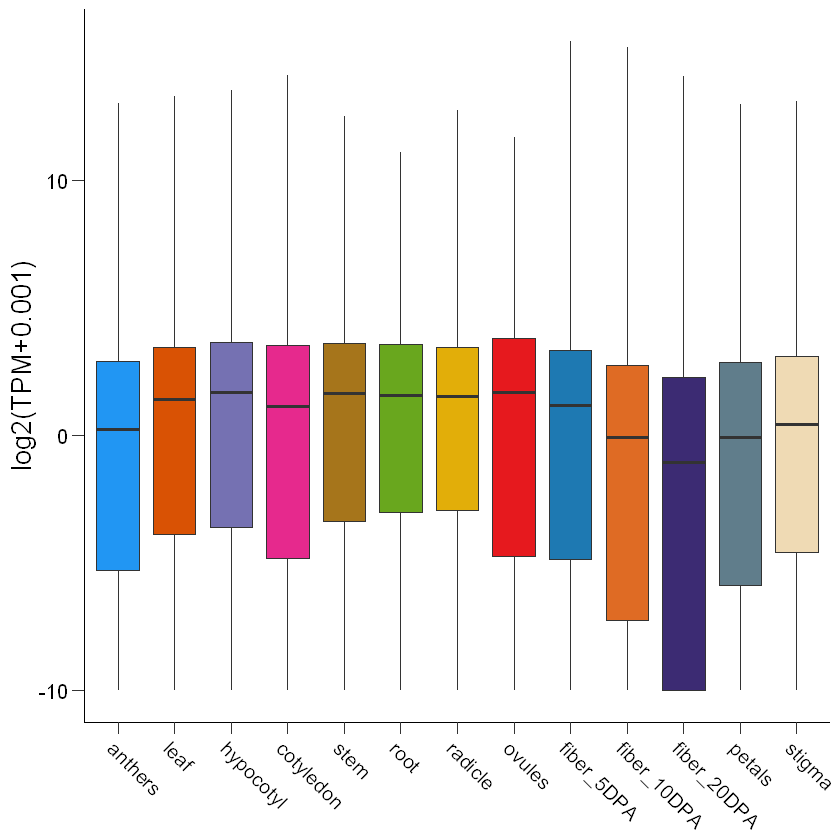

In [10]:
## 分析所有组织基因表达水平差异
## 分析不同类型的loop对于基因表达的影响
#endregionoptions(repr.plot.width=12, repr.plot.height=15)
library(ggplot2)
library(reshape2)
rm(list = ls())
setwd("G:/Billfish/J668_multip_tissue_3D-genome/RNA_seq/expression_gene")
library(ggplot2)
library(ggpubr)
df <- read.csv("J668_all_tissue_average_TPM.txt", sep = "\t", header =T)
df_long <-  melt(df, id=c("GeneId"))
#print(df_long)
df_long <- within(df_long, variable <- factor(variable, levels = c('anthers', 'leaf', 'hypocotyl', 'cotyledon', 'stem', 'root', 'radicle', 'ovules', 'fiber_5DPA', 'fiber_10DPA', 'fiber_20DPA', 'petals', 'stigma')))
with(df_long, levels(variable))
#df_long
#compaired = list(c("A_A_short", "B_B_short"), c("B_B_short", "A_A_long"), c("A_A_long", "B_B_long"), c("A_A_short", "A_A_long"), c("B_B_short", "B_B_long"))
fg <- ggplot(df_long, aes(x = variable, y = log2(value+0.001), fill = variable)) +
geom_boxplot(outlier.colour = NA, notch = FALSE) +
#geom_point(colour = '#8C8C8C', alpha = 0.8)+
#coord_cartesian(ylim = c(0.5,2.7))+
labs(y = "log2(TPM+0.001)", x = NULL) +
theme(panel.background = element_blank(),
     panel.grid = element_blank(),
     axis.line = element_line(linetype = 1),
     legend.position = "none",
     axis.ticks.length = unit(0.25, "cm"),
     axis.text = element_text(color = "black"),
     axis.text.x = element_text(angle = 315, hjust=0, size=12),
     axis.text.y = element_text(size=12),
     strip.text.x = element_text(size=14),
     axis.title.y = element_text(size=16)
     ) +
     scale_fill_manual(values = c("#2196F3", "#D95204", "#7571B2", "#E6298D", "#A6751B", "#69A71E", "#E2AE09", "#E6191E", "#1E79B2", "#df6b24", '#3C2B73', "#607D8B", "#efdab4"))
    # geom_signif(comparisons = compaired, step_increase = 0.05,test =wilcox.test, tip_length=0.01, textsize = 2, y_position=2)
fg
# ggsave(plot =fg, filename = 'all_sample_cis_strength_subg.pdf', height =15, width = 12)
# ggsave(plot =fg, filename = 'all_sample_cis_strength_subg.png', height =15, width = 12)


In [13]:
ggsave(plot =fg, filename = 'J668_all_tissue_average_TPM.pdf', height =4, width = 3.5)
ggsave(plot =fg, filename = 'J668_all_tissue_average_TPM.png', height =4, width = 3.5)

[1] "anthers"     "leaf"        "hypocotyl"   "cotyledon"   "stem"       
 [6] "root"        "radicle"     "ovules"      "fiber_5DPA"  "fiber_10DPA"
[11] "fiber_20DPA" "petals"      "stigma"

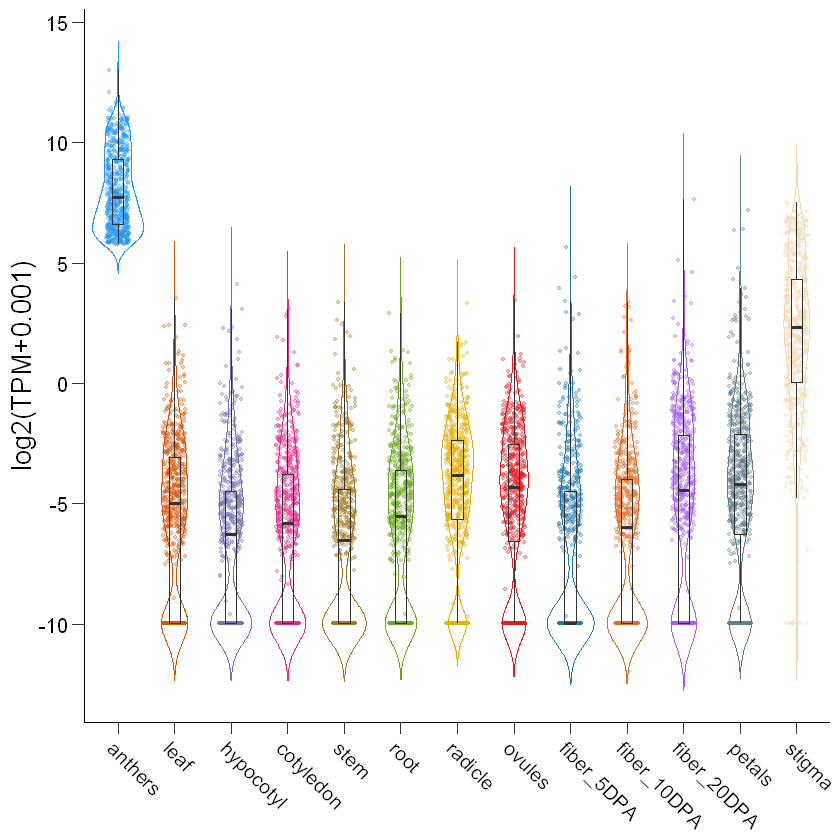

In [4]:
## 分析lemon-tree 鉴定的cluster其基因表达情况
library(ggplot2)
library(reshape2)
rm(list = ls())
setwd("G:/Billfish/J668_multip_tissue_3D-genome/RNA_seq/cluster/lemon_cluster_TPM")
library(ggplot2)
library(ggpubr)
df <- read.csv("lemon-tree_clusters_TPM.txt", sep = "\t", header =T)
df_long <-  melt(df, id=c("GeneId", "cluster_id", "std"))
#print(df_long)
df_long <- within(df_long, variable <- factor(variable, levels = c('anthers', 'leaf', 'hypocotyl', 'cotyledon', 'stem', 'root', 'radicle', 'ovules', 'fiber_5DPA', 'fiber_10DPA', 'fiber_20DPA', 'petals', 'stigma')))
with(df_long, levels(variable))
#df_long_cluster <- df_long[df_long$cluster_id==182, ]
#df_long_cluster <- df_long[df_long$cluster_id==295, ]
df_long_cluster <- df_long[df_long$cluster_id==0, ]
#compaired = list(c("A_A_short", "B_B_short"), c("B_B_short", "A_A_long"), c("A_A_long", "B_B_long"), c("A_A_short", "A_A_long"), c("B_B_short", "B_B_long"))
fg <- ggplot(df_long_cluster, aes(x = variable, y = log2(value+0.001))) +
geom_violin(trim=F, aes(col=variable)) +
geom_jitter(width=0.2, size=0.8, aes(col=variable), alpha = 0.3)+
geom_boxplot(outlier.colour = NA, notch = FALSE, width = 0.2, fill = NA) +
#geom_point(colour = '#8C8C8C', alpha = 0.8)+
#coord_cartesian(ylim = c(0.5,2.7))+
labs(y = "log2(TPM+0.001)", x = NULL) +
theme(panel.background = element_blank(),
     panel.grid = element_blank(),
     axis.line = element_line(linetype = 1),
     legend.position = "none",
     axis.ticks.length = unit(0.25, "cm"),
     axis.text = element_text(color = "black"),
     axis.text.x = element_text(angle = 315, hjust=0, size=12),
     axis.text.y = element_text(size=12),
     strip.text.x = element_text(size=12),
     axis.title.y = element_text(size=16)
     ) +
    #scale_fill_manual(values = c("#2196F3", "#D95204", "#7571B2", "#E6298D", "#A6751B", "#69A71E", "#E2AE09", "#E6191E", "#1E79B2", "#df6b24", '#3C2B73', "#607D8B", "#efdab4"))
    scale_color_manual(values = c("#2196F3", "#D95204", "#7571B2", "#E6298D", "#A6751B", "#69A71E", "#E2AE09", "#E6191E", "#1E79B2", "#df6b24", '#A55CED', "#607D8B", "#efdab4"))
    # geom_signif(comparisons = compaired, step_increase = 0.05,test =wilcox.test, tip_length=0.01, textsize = 2, y_position=2)
fg
ggsave(plot =fg, filename = 'lemon-tree_clusters_0.png', height =4, width = 4)
ggsave(plot =fg, filename = 'lemon-tree_clusters_0.pdf', height =4, width = 4)